## **Word Embeddings**

In [16]:
!pip install scikit-learn pandas numpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt

# Load Reddit
reddit_corpus = pd.read_csv("../data/Reddit/reddit_clean.csv")
print(reddit_corpus.tail())

# Load Rappler
rappler_corpus = pd.read_csv("../data/News/rappler_clean.csv")
print(rappler_corpus.tail())


                                              post_title  \
12725  Philippines, Japan deepen ties with $1.5 billi...   
12726  Philippines, Japan deepen ties with $1.5 billi...   
12727  Philippines, Japan deepen ties with $1.5 billi...   
12728  Philippines, Japan deepen ties with $1.5 billi...   
12729  Philippines, Japan deepen ties with $1.5 billi...   

                                                post_url  \
12725  https://reddit.com/r/Philippines/comments/1cio...   
12726  https://reddit.com/r/Philippines/comments/1cio...   
12727  https://reddit.com/r/Philippines/comments/1cio...   
12728  https://reddit.com/r/Philippines/comments/1cio...   
12729  https://reddit.com/r/Philippines/comments/1cio...   

                                                 comment post_body  \
12725                       that’s why fuck the dutertes       NaN   
12726                                  fr? that's scary.       NaN   
12727                  this partnership is very daijoubu       NaN  

In [18]:
reddit_texts = reddit_corpus["post_full"].astype(str).tolist()
rappler_texts = rappler_corpus["text"].astype(str).tolist()


In [19]:
# Stopwrods

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
english_stop = stopwords.words("english")

filipino_stopwords = [
    "sa","ang","ng","mga","si","ni","kay","kina",
    "ito","iyan","iyon","doon","diyan","dito",
    "ko","mo","nya","niya","natin","namin","nyo","ninyo",
    "sila","kami","tayo","kayo",
    "ay","may","wala","meron","naman","rin","din",
    "pa","ba","po","ho","eh","yung","yup","nope",
    "kung","kapag","pero","kasi","para","habang","bago",
    "nga","lang","daw","raw","yata","pala","talaga",
    "siguro","naka","ni","siya",
    
    # noise words
    "haha","hahaha","hehe","lol","omg","hmmmm","hmmmmmm",
    "tsk","hay","amp","grabe",
    
    # more noise as the code is ran
    "lalala", "brgy", "sen", "ph", "phl", "gov",
    "committee", "chairmanships"
]

combined_stopwords = list(set(english_stop + filipino_stopwords))



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Uwie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
**Reddit BoW**

In [20]:
bow_vectorizer = CountVectorizer(
    stop_words=combined_stopwords,
    max_df=0.85,
    min_df=5,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)


reddit_bow = bow_vectorizer.fit_transform(reddit_texts)
reddit_bow.shape


(12730, 1132)

In [21]:
vocab = bow_vectorizer.get_feature_names_out()
print(vocab[:50])     # first 50 words
print(len(vocab))     # vocabulary size


['aangkat' 'abs' 'acala' 'accept' 'account' 'accounts' 'achieve' 'act'
 'actually' 'ad' 'address' 'addressed' 'administration' 'advantage'
 'advocacy' 'advocates' 'aeta' 'african' 'age' 'agency' 'ago' 'agrarian'
 'agree' 'agri' 'agricultural' 'agriculture' 'agridom' 'ahensya' 'aide'
 'aired' 'ako' 'alam' 'alcala' 'allegedly' 'alleviate' 'allocated'
 'allocations' 'almost' 'already' 'also' 'always' 'aminado' 'among'
 'analysis' 'analytics' 'ancestral' 'andrew' 'animal' 'animals'
 'announced']
1132


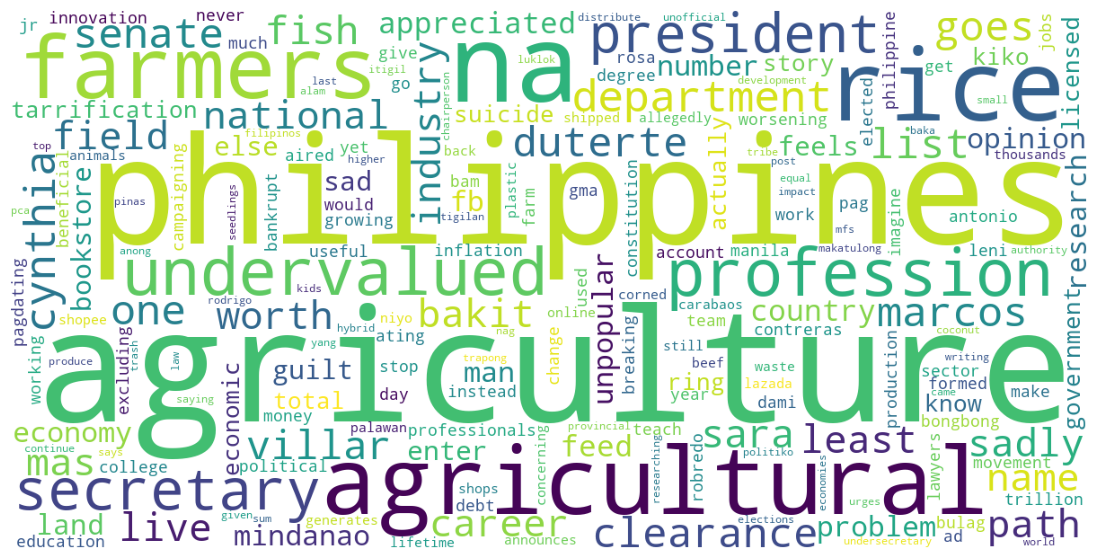

In [22]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt

word_freq = np.asarray(reddit_bow.sum(axis=0)).flatten()
freq_dict = dict(zip(vocab, word_freq))

plt.figure(figsize=(15, 7))
wordcloud = WordCloud(width=1200, height=600, background_color="white")
plt.imshow(wordcloud.generate_from_frequencies(freq_dict))
plt.axis("off")
plt.show()


---
**Rappler BoW**

In [23]:
import pandas as pd

rappler_corpus = pd.read_csv("../data/News/rappler_clean.csv")
rappler_corpus.tail()

texts_rappler = rappler_corpus["text"].astype(str)


In [24]:
from sklearn.feature_extraction.text import CountVectorizer

rappler_vectorizer = CountVectorizer(
    stop_words=combined_stopwords,
    max_df=0.85,
    min_df=5,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'  # letters only
)

rappler_bow = rappler_vectorizer.fit_transform(texts_rappler)
rappler_bow.shape


(121, 1391)

In [25]:
rappler_vocab = rappler_vectorizer.get_feature_names_out()
print(len(rappler_vocab))
print(rappler_vocab[:50])


1391
['ability' 'able' 'absorb' 'access' 'accessible' 'according' 'achieve'
 'across' 'act' 'active' 'actively' 'activities' 'actually' 'added'
 'addition' 'additional' 'address' 'administration' 'administrator'
 'adopting' 'advanced' 'advantage' 'affect' 'affected' 'affordable'
 'africa' 'african' 'age' 'agencies' 'agency' 'ago' 'agrarian' 'agreement'
 'agri' 'agribusiness' 'agricultural' 'agriculture' 'agrikultura' 'aims'
 'ako' 'alleged' 'allocation' 'allow' 'allowed' 'almost' 'alone' 'along'
 'already' 'also' 'although']


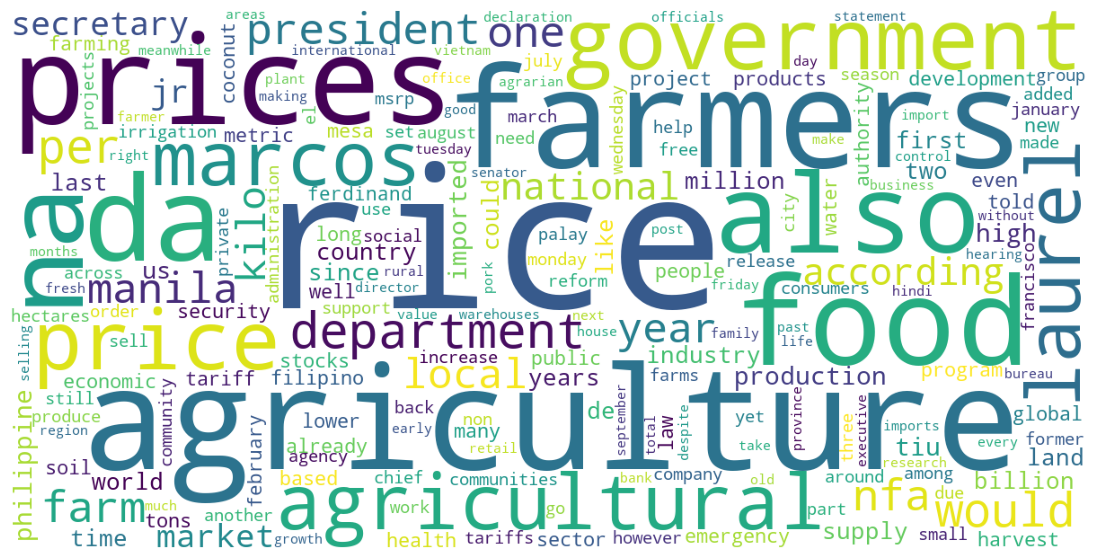

In [26]:
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt

rappler_freq = np.asarray(rappler_bow.sum(axis=0)).flatten()
rappler_freq_dict = dict(zip(rappler_vocab, rappler_freq))

plt.figure(figsize=(15,7))
wc = WordCloud(width=1200, height=600, background_color="white")
plt.imshow(wc.generate_from_frequencies(rappler_freq_dict))
plt.axis("off")
plt.show()
